In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
# Configure chart aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Listing all CSV files in the current folder to confirm the exact name
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("CSV files found in folder:", csv_files)

CSV files found in folder: ['retail_sales_dataset.csv']


In [9]:
# Loading dataset using the detected file name
file_name = csv_files[0] if csv_files else 'retail_sales_dataset.csv'
df = pd.read_csv(file_name)

In [10]:
# Converting Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
# Initial structural inspection
print("\n=== DATASET OVERVIEW ===")
print(f"Loaded File: {file_name}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}\n")

df.head()


=== DATASET OVERVIEW ===
Loaded File: retail_sales_dataset.csv
Rows: 1000 | Columns: 9
Missing Values: 0
Duplicate Rows: 0



,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [13]:
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
desc_stats = df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0


In [15]:
#  Adding median and mode explicitly
desc_stats['median'] = df[num_cols].median()
desc_stats['mode'] = df[num_cols].mode().iloc[0]

In [19]:
desc_stats = desc_stats[['mean', 'median', 'mode', 'std', 'min', '25%', '50%', '75%', 'max']]

print("=== NUMERICAL DESCRIPTIVE STATISTICS ===")
display(desc_stats)

=== NUMERICAL DESCRIPTIVE STATISTICS ===


,mean,median,mode,std,min,25%,50%,75%,max
Age,41.392,42.0,43.0,13.681430,18.0,29.0,42.0,53.0,64.0
Quantity,2.514,3.0,4.0,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,179.890,50.0,50.0,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,456.000,135.0,50.0,559.997632,25.0,60.0,135.0,900.0,2000.0


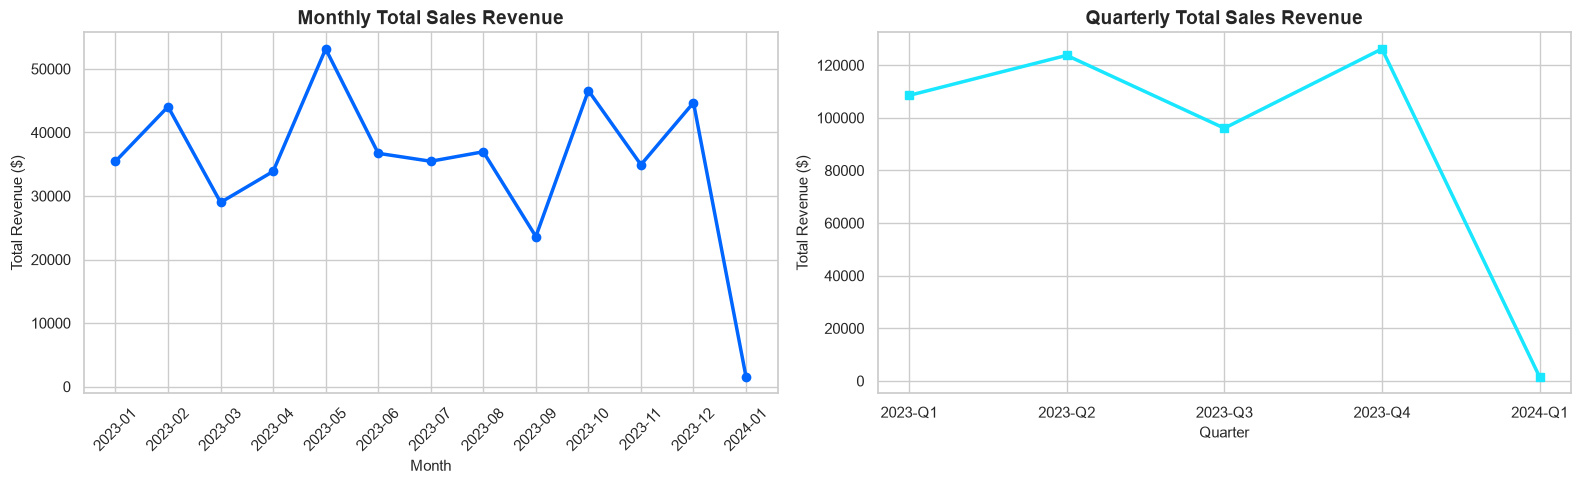

In [21]:
# 1. Resample Total Amount by Month End ('ME') and Quarter End ('QE')
monthly_sales = df.set_index('Date').resample('ME')['Total Amount'].sum()
quarterly_sales = df.set_index('Date').resample('QE')['Total Amount'].sum()

# 2. Setup double plot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly Trend Plot
axes[0].plot(monthly_sales.index.strftime('%Y-%m'), monthly_sales.values, marker='o', color='#0066FF', linewidth=2.5)
axes[0].set_title('Monthly Total Sales Revenue', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Total Revenue ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# Quarterly Trend Plot
quarter_labels = [f"{dt.year}-Q{dt.quarter}" for dt in quarterly_sales.index]
axes[1].plot(quarter_labels, quarterly_sales.values, marker='s', color='#19E6FF', linewidth=2.5)
axes[1].set_title('Quarterly Total Sales Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter', fontsize=11)
axes[1].set_ylabel('Total Revenue ($)', fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\alee_\AppData\Local\Temp\ipykernel_14492\2913272207.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0], palette=['#0066FF', '#19E6FF'])
C:\Users\alee_\AppData\Local\Temp\ipykernel_14492\2913272207.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[1], palette='Blues_r')


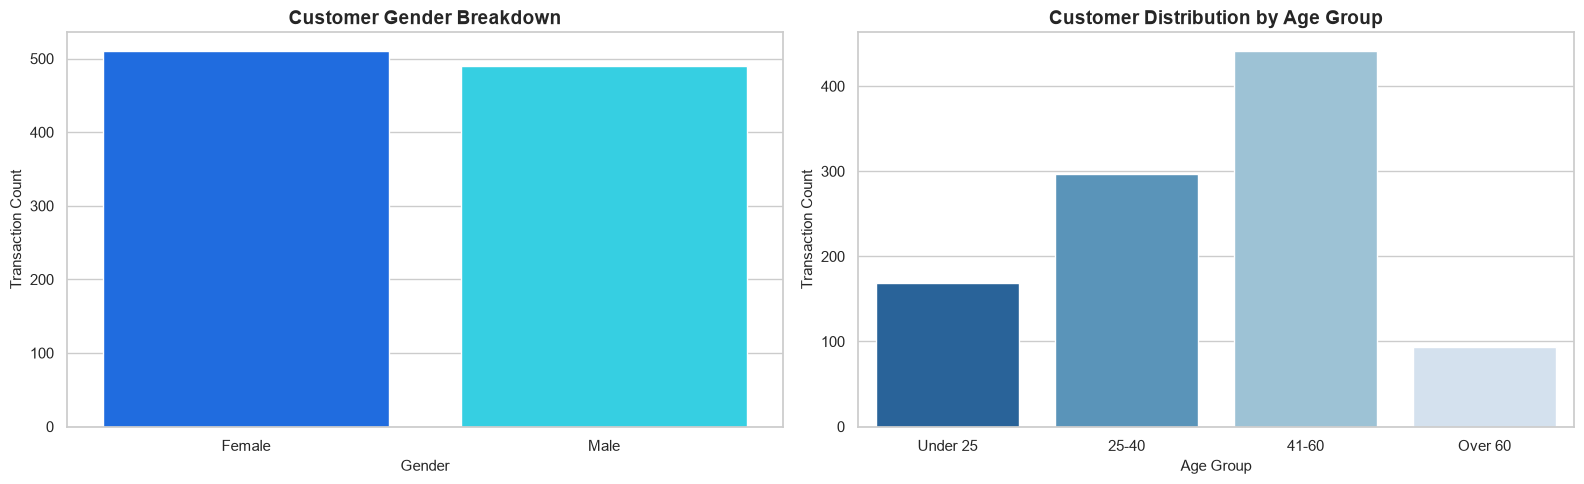

In [22]:
# 1. Bin Age into demographic brackets
age_bins = [0, 25, 40, 60, 100]
age_labels = ['Under 25', '25-40', '41-60', 'Over 60']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 2. Setup plot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gender Breakdown Plot
gender_counts = df['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0], palette=['#0066FF', '#19E6FF'])
axes[0].set_title('Customer Gender Breakdown', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Transaction Count', fontsize=11)

# Age Group Distribution Plot
age_counts = df['Age Group'].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Customer Distribution by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=11)
axes[1].set_ylabel('Transaction Count', fontsize=11)

plt.tight_layout()
plt.show()

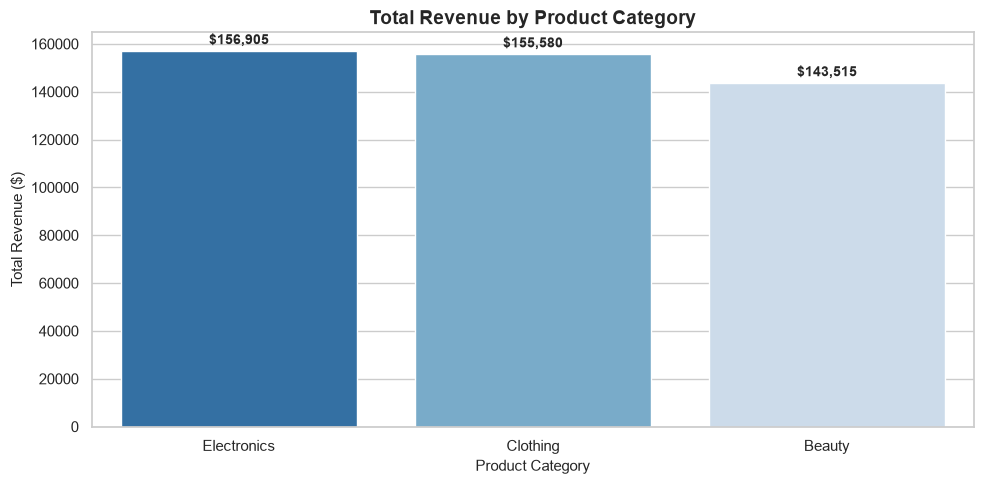

,Product Category,Total Amount,Quantity,Transaction Count
2,Electronics,156905,849,342
1,Clothing,155580,894,351
0,Beauty,143515,771,307


In [23]:
# 1. Aggregate Total Revenue and Quantity by Product Category
category_summary = df.groupby('Product Category').agg({
    'Total Amount': 'sum',
    'Quantity': 'sum',
    'Transaction ID': 'count'
}).rename(columns={'Transaction ID': 'Transaction Count'}).reset_index()

# Sort by Total Revenue descending
category_summary = category_summary.sort_values(by='Total Amount', ascending=False)

# 2. Plot Revenue by Product Category
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=category_summary,
    x='Product Category',
    y='Total Amount',
    hue='Product Category',
    palette='Blues_r',
    legend=False
)

plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)

# Add data value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), 
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Display summary table below chart
display(category_summary)

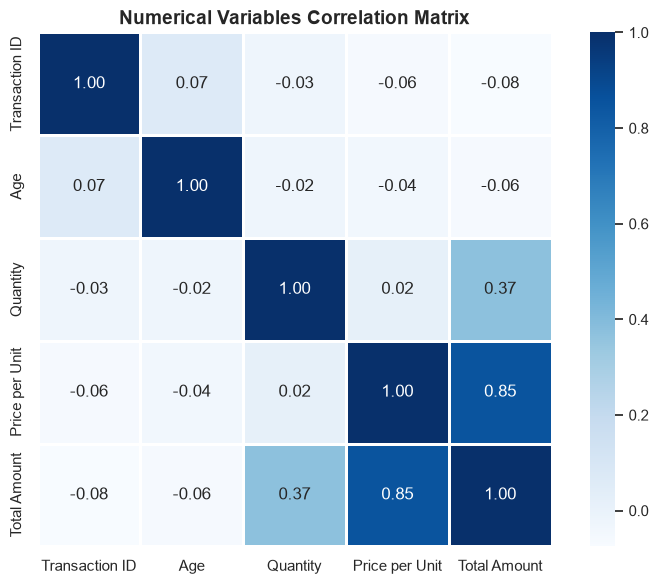

In [24]:
# 1. Select numerical columns for correlation analysis
num_features = df.select_dtypes(include=[np.number]).columns

# 2. Compute Pearson correlation matrix
corr_matrix = df[num_features].corr()

# 3. Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    linewidths=1, 
    cbar=True,
    square=True
)

plt.title('Numerical Variables Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

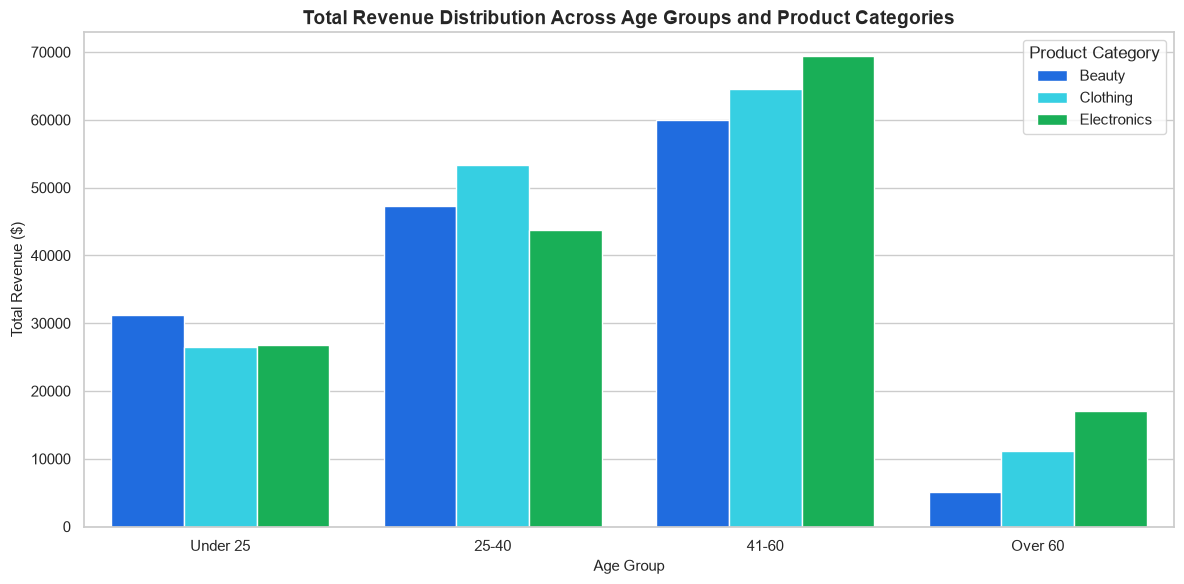

In [25]:
# 1. Aggregate Total Revenue by Age Group and Product Category
age_cat_revenue = df.groupby(['Age Group', 'Product Category'], observed=False)['Total Amount'].sum().reset_index()

# 2. Plot Grouped Bar Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=age_cat_revenue,
    x='Age Group',
    y='Total Amount',
    hue='Product Category',
    palette=['#0066FF', '#19E6FF', '#00C853']
)

plt.title('Total Revenue Distribution Across Age Groups and Product Categories', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.legend(title='Product Category', frameon=True)

plt.tight_layout()
plt.show()

## 📊 Key Findings & Business Recommendations

### 1. Key Insights & Observations
* **Demographic Concentration:** Customers aged **41–60** generate the highest revenue share across all product categories, making them the primary economic driver for the business.
* **Category Balance:** Revenue is evenly split among **Electronics** ($156.9K), **Clothing** ($155.5K), and **Beauty** ($143.5K), showing strong cross-category engagement without heavy over-reliance on a single product line.
* **Linear Drivers:** `Total Amount` correlates strongly with `Price per Unit` (0.85) and moderately with `Quantity` (0.37), indicating that premium higher-priced inventory drives revenue more effectively than volume bundling.

---

### 2. Strategic Actionable Recommendations

1. **Targeted Campaigns for High-Value Demographics:**
   * Direct marketing budgets toward middle-aged professionals (ages 41–60) through tailored email sequences and loyalty programs featuring premium Electronics and Clothing lines.

2. **Cross-Category Bundling Strategies:**
   * Create promotional bundles pairing top-selling Electronics items with Beauty/Clothing accessories to lift basket size for younger shoppers (Under 25) and senior demographics (Over 60).

3. **Inventory & Seasonal Optimization:**
   * Align stock replenishment cycles with identified quarterly revenue peaks to minimize stockouts during high-demand months while maintaining lean inventory during seasonal dips.